# Copyright
<pre>
Jelen forráskód a Budapesti Műszaki és Gazdaságtudományi Egyetemen tartott
"Deep Learning a gyakorlatban Python és LUA alapon" tantárgy segédanyagaként készült.

A tantárgy honlapja: http://smartlab.tmit.bme.hu/oktatas-deep-learning
Deep Learning kutatás: http://smartlab.tmit.bme.hu/deep-learning

A forráskódot GPLv3 licensz védi. Újrafelhasználás esetén lehetőség szerint kérjük
az alábbi szerzőt értesíteni.

2021 (c) Csapó Tamás Gábor (csapot kukac tmit pont bme pont hu),
Gyires-Tóth Bálint, Zainkó Csaba


Original Variational AutoEncoder example from:

Links:
[Louis Tiao blog] http://louistiao.me/posts/implementing-variational-autoencoders-in-keras-beyond-the-quickstart-tutorial/
[Keras Variational AutoEncoder] https://blog.keras.io/building-autoencoders-in-keras.html
https://raw.githubusercontent.com/fchollet/keras/master/examples/variational_autoencoder.py
[Auto-Encoding Variational Bayes] https://arxiv.org/abs/1312.6114
</pre>

In [1]:
# ezeket érdemes előre feltenni, mert pár percig eltarthat a telepítés (plot_model-hez kell)
!pip install -q pydot
!apt install graphviz
!pip install tensorflow==2.15

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Successfully uninstalled wrapt-1.16.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-

In [2]:
from tensorflow.keras.layers import Input, Dense, Lambda, Layer, Multiply, Add
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.metrics import binary_crossentropy
from tensorflow.keras.utils import plot_model
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

In [3]:
# Variational AutoEncoder-t fogunk készíteni, ami az MNIST digitekhez generál új képeket

batch_size = 100
original_dim = 784 # MNIST képek mérete
latent_dim = 2 # látens dimenzió: 2D
intermediate_dim = 256 # belső 'AutoEncoder' jellegű tömörítés
epochs = 15


In [4]:
# nézd meg a VAE hálózat általános alakját (előadás fólia)

# először egy egyszerű dekóder hálózat

decoder = Sequential([
    Dense(intermediate_dim, input_dim=latent_dim, activation='relu'),
    Dense(original_dim, activation='sigmoid')
])

decoder.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               768       
                                                                 
 dense_1 (Dense)             (None, 784)               201488    
                                                                 
Total params: 202256 (790.06 KB)
Trainable params: 202256 (790.06 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


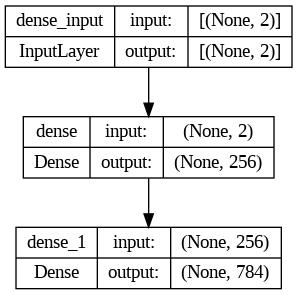

In [5]:
# dekóder modell grafikus kirajzolása
plot_model(decoder, show_shapes=True, show_layer_names=True)

In [6]:
# encoder hálózat (inference)

# bemeneti réteg
x = Input(shape=(original_dim,))

# rejtett réteg
h = Dense(intermediate_dim, activation='relu')(x)

# kimeneti réteg: átlag és a variancia logaritmusa
z_mu = Dense(latent_dim)(h)
z_log_var = Dense(latent_dim)(h)


In [7]:
# a VAE hálózat közepén van egy KL-divergencia számítás,
# amit egyéni réteg megírásával oldunk meg

class KLDivergenceLayer(Layer):

    """ Identity transform layer that adds KL divergence
    to the final model loss.
    """

    def __init__(self, *args, **kwargs):
        self.is_placeholder = True
        super(KLDivergenceLayer, self).__init__(*args, **kwargs)

    def call(self, inputs):

        mu, log_var = inputs

        kl_batch = - .5 * tf.reduce_sum(1 + log_var -
                                        tf.math.square(mu) -
                                        tf.math.exp(log_var), axis=-1)

        self.add_loss(tf.reduce_mean(kl_batch))

        return inputs


In [8]:
# az eddigiek összerakása

# KL-divergencia réteg...
z_mu, z_log_var = KLDivergenceLayer()([z_mu, z_log_var])

# 'var': variancia = szórásnégyzet
# log varianciából kiszámítjuk a szórást
z_sigma = Lambda(lambda t: tf.math.exp(.5*t))(z_log_var)

# normál eloszlású zaj lesz
eps = Input(shape=(latent_dim,))

# keras Merge rétegek (Multiply, Add) : reparameterization
z_eps = Multiply()([z_sigma, eps])
z = Add()([z_mu, z_eps])

# dekóder
x_pred = decoder(z)

In [9]:
# a hibafüggvény most egyéni lesz: negatív log-likelihood

# log_pθ(x|z)
def nll(y_true, y_pred):
    """ Negative log likelihood (Bernoulli). """

    # keras.losses.binary_crossentropy gives the mean
    # over the last axis. we require the sum
    return tf.reduce_sum(binary_crossentropy(y_true, y_pred), axis=-1)

In [10]:
# teljes VAE modell
vae = Model(inputs=[x, eps], outputs=x_pred)
vae.compile(optimizer='rmsprop', loss=nll)

In [11]:
vae.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 784)]                0         []                            
                                                                                                  
 dense_2 (Dense)             (None, 256)                  200960    ['input_1[0][0]']             
                                                                                                  
 dense_3 (Dense)             (None, 2)                    514       ['dense_2[0][0]']             
                                                                                                  
 dense_4 (Dense)             (None, 2)                    514       ['dense_2[0][0]']             
                                                                                              

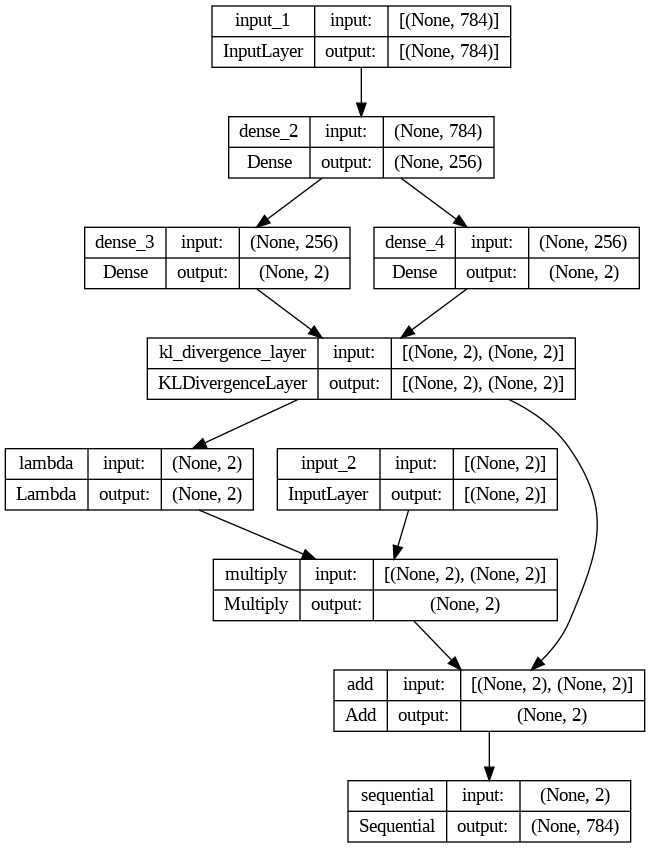

In [12]:
# hasonlítsuk össze a mi hálónkat a VAE általános alakjával,
# (előadás fólia)

plot_model(vae, show_shapes=True, show_layer_names=True)

In [13]:
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, original_dim) / 255.
x_test = x_test.reshape(-1, original_dim) / 255.

11490434/11490434 [==============================] - 0s 0us/step


In [14]:
noise_train = np.random.normal(size=[x_train.shape[0], latent_dim])
noise_test = np.random.normal(size=[x_test.shape[0], latent_dim])

In [15]:
# a VAE-t úgy tanítjuk, hogy a bemenet és kimenet egyezik:
# az input és a target is x_train

vae.fit([x_train, noise_train],
        x_train,
        shuffle=True,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=([x_test, noise_test], x_test))

Epoch 1/15
600/600 [==============================] - 10s 8ms/step - loss: 27.1272 - val_loss: 24.4512
Epoch 2/15
600/600 [==============================] - 4s 6ms/step - loss: 24.2753 - val_loss: 24.1811
Epoch 3/15
600/600 [==============================] - 3s 5ms/step - loss: 24.0459 - val_loss: 24.0135
Epoch 4/15
600/600 [==============================] - 2s 4ms/step - loss: 23.9046 - val_loss: 23.9201
Epoch 5/15
600/600 [==============================] - 2s 4ms/step - loss: 23.7935 - val_loss: 23.8317
Epoch 6/15
600/600 [==============================] - 2s 4ms/step - loss: 23.7029 - val_loss: 23.7973
Epoch 7/15
600/600 [==============================] - 2s 4ms/step - loss: 23.6270 - val_loss: 23.7140
Epoch 8/15
600/600 [==============================] - 3s 5ms/step - loss: 23.5605 - val_loss: 23.6947
Epoch 9/15
600/600 [==============================] - 2s 4ms/step - loss: 23.4981 - val_loss: 23.6455
Epoch 10/15
600/600 [==============================] - 2s 4ms/step - loss: 23.439

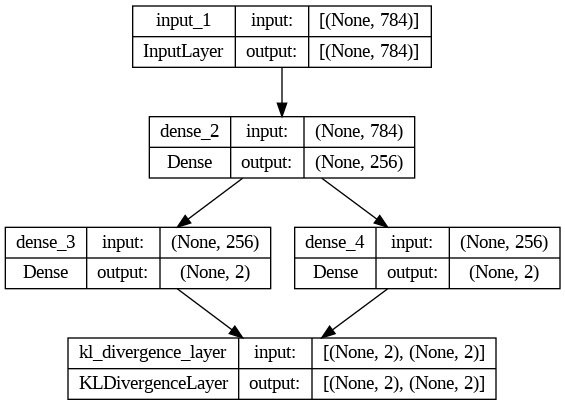

In [16]:
# modell kiértékelése

# enkóder: eredeti képek -> látens tér (2D)
encoder = Model(x, z_mu)

plot_model(encoder, show_shapes=True, show_layer_names=True)

100/100 [==============================] - 0s 1ms/step


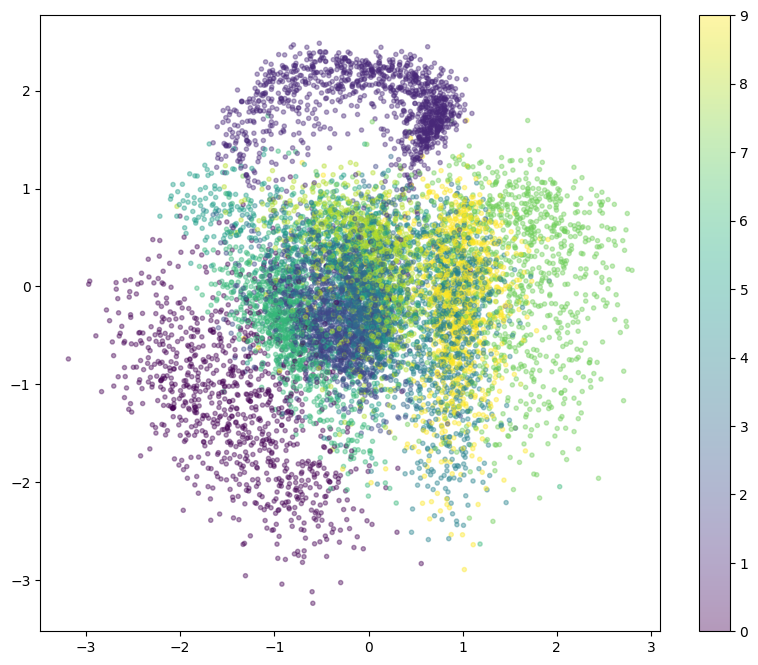

In [17]:
# digit osztályok kirajzolása 2D-ben, a látens térben
# azt érdemes észrevenni, hogy az egyes digitek (különböző színek)
# egész jól elkülönülnek

# enkóder: eredeti képek -> látens tér (2D)

z_test = encoder.predict(x_test, batch_size=batch_size)
plt.figure(figsize=(10, 8))
plt.scatter(z_test[:, 0], z_test[:, 1], c=y_test,
            alpha=.4, s=3**2, cmap='viridis')
plt.colorbar()
plt.show()

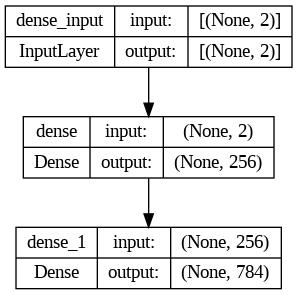

In [18]:
# dekóder újra, emlékeztetőnek
# a 2D látens reprezentációból tud majd új digiteket generálni

plot_model(decoder, show_shapes=True, show_layer_names=True)


1/1 [==============================] - 0s 155ms/step


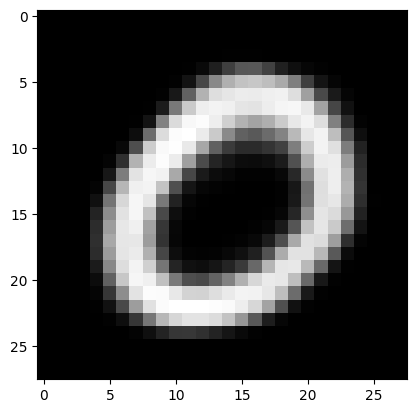

In [19]:
# véletlen képek generálása
# (többször le lehet futtatni, és mutatni jobb / rosszabb példákat)
z_sample = norm.ppf(np.random.rand(1,2))
generated_digit = decoder.predict(z_sample)
plt.imshow(generated_digit.reshape(28,28), cmap='gray')
plt.show()

1/1 [==============================] - 0s 16ms/step


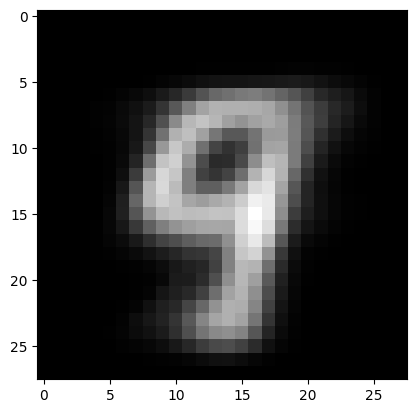

In [20]:
# véletlen képek generálása
# (többször le lehet futtatni, és mutatni jobb / rosszabb példákat)
z_sample = norm.ppf(np.random.rand(1,2))
generated_digit = decoder.predict(z_sample)
plt.imshow(generated_digit.reshape(28,28), cmap='gray')
plt.show()

8/8 [==============================] - 0s 2ms/step


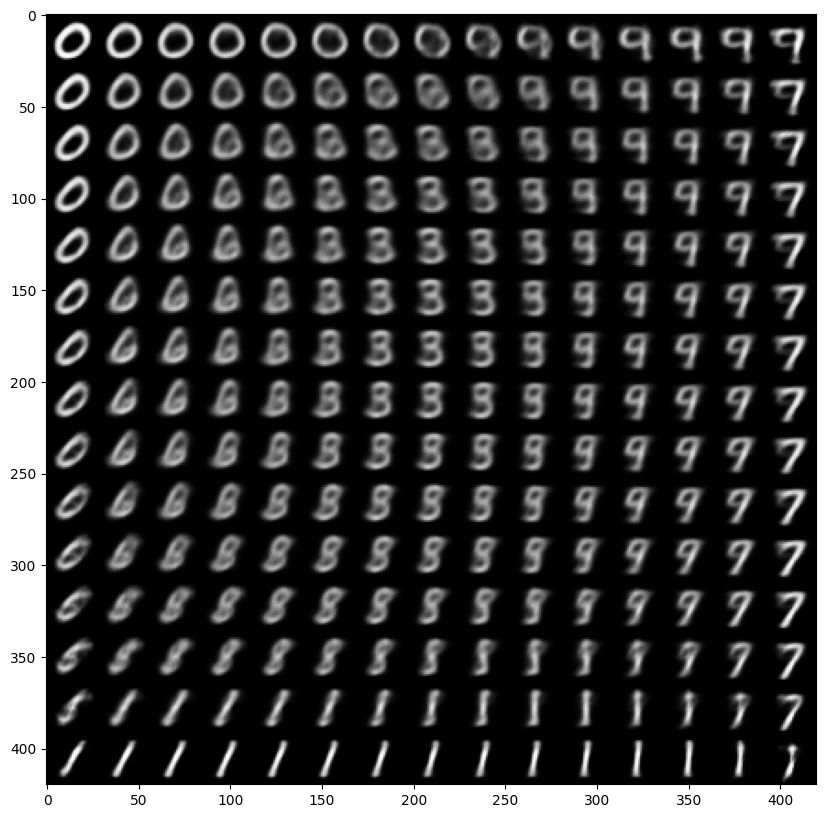

In [21]:
# digitek 2D síkon ábrázolva
n = 15  # 15x15 digit
digit_size = 28

# linearly spaced coordinates on the unit square were transformed
# through the inverse CDF (ppf) of the Gaussian to produce values
# of the latent variables z, since the prior of the latent space
# is Gaussian

z1 = norm.ppf(np.linspace(0.01, 0.99, n))
z2 = norm.ppf(np.linspace(0.01, 0.99, n))

z_grid = np.dstack(np.meshgrid(z1, z2))

x_pred_grid = decoder.predict(z_grid.reshape(n*n, latent_dim)) \
                     .reshape(n, n, digit_size, digit_size)

plt.figure(figsize=(10, 10))
plt.imshow(np.block(list(map(list, x_pred_grid))), cmap='gray')
plt.show()

In [22]:
# itt a vége.
# ami tehát összefoglalás: a Variational Autoencoder nevében hasonlít az AutoEncoder hálózatokhoz,
# de valójában itt a lényeg már a generatív modellezés